# Porting from R to Python, side-by-side

**Audience:** you have R scripts that use `RobStatTM`, and you want to translate them to Python without learning a new API. This notebook shows every common R idiom next to its Python equivalent.

Two import styles are supported:

```python
import robstattm_py as rpm                # canonical snake_case (recommended)
from robstattm_py.compat_r import *       # keep the R names verbatim
```

We'll use **both** in the same notebook so you can see they're interchangeable.

In [1]:
import os, sys

import numpy as np
import robstattm_py as rpm
from robstattm_py.compat_r import *      # gives us lmrobdetMM, covRobMM, ... directly

## 1. Loading data

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>data(mineral, package='RobStatTM')
head(mineral)</pre></td>
<td><pre>df = rpm.datasets.mineral()
df.head()</pre></td></tr></table>

In [2]:
df = rpm.datasets.mineral()
df.head()

,copper,zinc
1,102.0,4.0
2,96.0,56.0
3,265.0,2.0
4,185.0,8.0
5,229.0,26.0


## 2. Robust MM regression

<table style='width:100%'><tr><th>R</th><th>Python (snake_case)</th><th>Python (R-name alias)</th></tr>
<tr><td><pre>fit <- lmrobdetMM(
  zinc ~ copper,
  data = mineral)
summary(fit)</pre></td>
<td><pre>fit = rpm.lmrobdet_mm(
  'zinc ~ copper',
  data=df)
print(fit.summary())</pre></td>
<td><pre>fit = lmrobdetMM(
  'zinc ~ copper',
  data=df)
print(fit.summary())</pre></td></tr></table>

In [3]:
fit = lmrobdetMM('zinc ~ copper', data=df)
print(fit.summary())

R callback write-console: Registered S3 method overwritten by 'robustbase':
  method          from     
  hatvalues.lmrob RobStatTM
  


Call: lmrobdetMM-family(zinc ~ copper)

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)
(Intercept)    15.201      2.2532   6.7465 1.3686e-08
copper       0.012561    0.022269  0.56408    0.57517

Robust residual standard error: 9.997
Multiple R-squared: 0.008201, Adjusted R-squared: -0.01125
Convergence in 17 IRWLS iterations


## 3. Extracting components

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>coef(fit)
fit$scale
fit$r.squared
residuals(fit)
fitted(fit)
predict(fit, newdata)
hatvalues(fit)
fit$rweights</pre></td>
<td><pre>fit.coefficients
fit.scale
fit.r_squared
fit.residuals
fit.fitted_values
fit.predict(newdata)
fit.hatvalues()
fit.rweights</pre></td></tr></table>

Rule of thumb: R dotted names become Python underscores (`r.squared` → `r_squared`), R S3 methods become Python methods (`predict(fit)` → `fit.predict()`).

In [4]:
print('coefficients :', fit.coefficients)
print('scale        :', fit.scale)
print('R²           :', fit.r_squared)
print('# obs flagged:', (fit.rweights < 0.5).sum())

coefficients : [1.52012174e+01 1.25614958e-02]
scale        : 9.996566341639118
R²           : 0.008201132297524215
# obs flagged: 4


## 4. Control objects (tuning parameters)

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>ctrl <- lmrobdet.control(
  family = 'bisquare',
  efficiency = 0.85)
fit2 <- lmrobdetMM(
  zinc ~ copper,
  data = mineral,
  control = ctrl)</pre></td>
<td><pre>ctrl = rpm.lmrobdet_control(
  family='bisquare',
  efficiency=0.85)
fit2 = rpm.lmrobdet_mm(
  'zinc ~ copper',
  data=df,
  control=ctrl)</pre></td></tr></table>

R dotted attribute names like `lmrobdet.control` become underscore, `lmrobdet_control`. The dataclass is frozen, so typos raise `TypeError` instead of silently passing through.

In [5]:
ctrl = rpm.lmrobdet_control(family='bisquare', efficiency=0.85)
fit2 = rpm.lmrobdet_mm('zinc ~ copper', data=df, control=ctrl)
print('coefficients with bisquare/0.85:', fit2.coefficients)

R callback write-console: In addition:   


R callback write-console: There were 50 or more warnings (use warnings() to see the first 50)  


R callback write-console: 
  


coefficients with bisquare/0.85: [12.91368166  0.04413551]


## 5. Robust covariance + PCA

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>set.seed(42)
cov <- covRobMM(wine)
cov$center
cov$cov
cov$dist

prc <- prcompRob(wine)
summary(prc)</pre></td>
<td><pre>rpm.set_seed(42)
cov = rpm.cov_rob_mm(wine)
cov.center
cov.cov
cov.dist

prc = rpm.prcomp_rob(wine)
prc.summary()</pre></td></tr></table>

In [6]:
wine = rpm.datasets.wine()
rpm.set_seed(42)
cov_fit = covRobMM(wine)
print('center[:3] :', cov_fit.center[:3])
print('first 3 evals:', cov_fit.summary().evals[:3])

center[:3] : [13.74826923  1.77480769  2.46211538]
first 3 evals: [4.88584100e+04 1.17014467e+02 6.50012912e+00]


## 6. Stepwise model selection (RFPE-based)

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>step.lmrobdetMM(
  full_fit,
  direction = 'backward',
  trace = FALSE)</pre></td>
<td><pre>rpm.step_lmrobdet(
  full_fit,
  direction='backward')</pre></td></tr></table>

Same RFPE criterion, same trace; Python returns a `StepResult` dataclass with `.formula_selected`, `.coefficients`, `.rfpe_trace`.

## 7. Robust linear hypothesis test

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>rob.linear.test(fit, drop = 'copper')</pre></td>
<td><pre>rpm.rob_linear_test(fit, drop=['copper'])</pre></td></tr></table>

R-name aliases also available: `lsRobTestMM`, `lmrobdetLinTest`.

## 8. Robust logistic regression

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>BYlogreg(X, y)
WBYlogreg(X, y)
WMLlogreg(X, y)</pre></td>
<td><pre>rpm.by_logreg(X=X, y=y)
rpm.wby_logreg(X=X, y=y)
rpm.wml_logreg(X=X, y=y)</pre></td></tr></table>

## 9. Plotting, keep R's exact graphics

When pixel-perfect fidelity with R-side plots matters, `rpm.plotting.r_plot()` runs raw R code in a PNG device and returns a path. Anything you can plot in R, you can render here:

<table style='width:100%'><tr><th>R</th><th>Python</th></tr>
<tr><td><pre>plot(
  zinc ~ copper,
  data = mineral,
  pch = 19)
abline(fit, col = 'red')</pre></td>
<td><pre>from robstattm_py.plotting \
  import r_plot, show_png
png = r_plot('''
  plot(zinc ~ copper,
       data=mineral, pch=19)
  abline(lmrobdetMM(zinc~copper,
         data=mineral), col='red')
''')
show_png(png)</pre></td></tr></table>

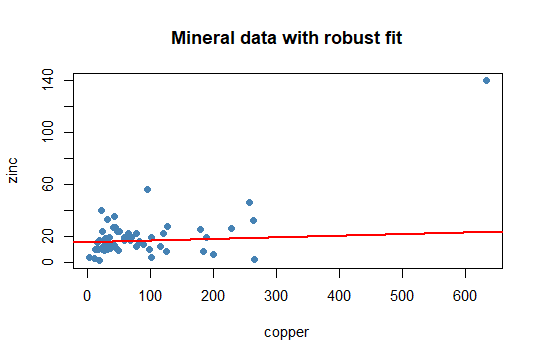

In [7]:
from robstattm_py.plotting import r_plot, show_png
png = r_plot("""
    plot(zinc ~ copper, data=mineral, pch=19, col='steelblue',
         main='Mineral data with robust fit')
    abline(lmrobdetMM(zinc ~ copper, data=mineral), col='red', lwd=2)
""", dpi=90, width=6, height=4)
show_png(png)

## 10. R-to-Python name cheatsheet

Every R name in `RobStatTM` maps to a Python name following one rule: **lowercase + underscore for dots and camelCase**.

```python
rpm.list_names()              # full R -> Python dict
rpm.help('lmrobdetMM')        # works with either R or Python name
rpm.help('lmrobdet_mm')       # same output
```

Common translations:

In [8]:
import pandas as pd
name_map = rpm.list_names()
highlights = ['lmrobdetMM', 'lmrobdetDCML', 'lmrobM', 'covRobMM', 'covRobRocke',
              'prcompRob', 'pcaRobS', 'BYlogreg', 'step.lmrobdetMM',
              'rob.linear.test', 'lmrobdet.control']
pd.DataFrame({'R name': highlights,
              'Python name': [name_map[n] for n in highlights]})

,R name,Python name
0,lmrobdetMM,lmrobdet_mm
1,lmrobdetDCML,lmrobdet_dcml
2,lmrobM,lmrob_m
3,covRobMM,cov_rob_mm
4,covRobRocke,cov_rob_rocke
5,prcompRob,prcomp_rob
6,pcaRobS,pca_rob_s
7,BYlogreg,by_logreg
8,step.lmrobdetMM,step_lmrobdet
9,rob.linear.test,rob_linear_test


## Things that work differently, short list

1. **Formulas are strings**, `'zinc ~ copper'`, not a bare expression.  R syntax inside the quotes works as-is, since rpy2 forwards it straight to R for parsing.
2. **Data must be a `pandas.DataFrame`**, not a `dict`, not a numpy array (except in the optional `(X, y)` form).
3. **Set the seed via `rpm.set_seed(n)`**, wraps R's `set.seed(n)` so stochastic estimators (`covRobMM`, `pyinit`) are reproducible.
4. **R `NULL` returns are surfaced as Python `None`**, e.g. `summary(lmrobdetDCML(...))$r.squared` is `None`, not 0.
5. **Round-trip back to R**, every fit has `fit.to_r()` if you need to keep working in R afterwards.

If you've got an R script and the translation isn't obvious, run `rpm.help('<r_name>')` and the canonical Python name + docstring will pop out.